<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_5/Day_1/ExercisesExercise_xp_w5_d1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise XP: Diabetes Classification
===

**Exercise 1 :**

Understanding the problem and Data Collection
We want to predict if an individual will have diabetes.

- Load the diabetes dataset and explore it.
- How many positive and negative cases is there ?
- Split the data into training and testing sets

In [ ]:
import pandas as pd

#Load the dataset
df = pd.read_csv('diabetes_prediction_dataset.csv')

#Basic Exploration
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Data Summary ---")
df.info()



--- Dataset Shape ---
(100000, 9)

--- First 5 Rows ---
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

--- Data Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   ----

In [ ]:
# Count positive and negative cases:

print("\n--- Target Variable Distribution ---")
print(df['diabetes'].value_counts())





--- Target Variable Distribution ---
diabetes
0    91500
1     8500
Name: count, dtype: int64


In [ ]:
#Splitting the Data:

from sklearn.model_selection import train_test_split

#Separate Features (X) and Target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

#Encoding
X = pd.get_dummies(X, columns=['gender', 'smoking_history'], drop_first=True)

#Split into Training and Testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Checking the results:
print(f"Total dataset: {len(df)} rows")
print(f"Training set: {len(X_train)} rows")
print(f"Testing set: {len(X_test)} rows")

Total dataset: 100000 rows
Training set: 80000 rows
Testing set: 20000 rows


_________________

**Exercise 2 :**

Model Picking and Standardization
Which classification model can we use in this problem and why ?
Do we need to standardize the data ? If yes, use .StandardScaler()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Data Standardized successfully!")
print(X_train[num_cols].head())

Data Standardized successfully!
            age  hypertension  heart_disease       bmi  HbA1c_level  \
75220  1.378720     -0.286309      -0.203559 -0.386474    -1.892451   
48955  1.689866     -0.286309      -0.203559 -0.412172     0.162169   
44966 -0.177011     -0.286309      -0.203559 -0.452986    -1.425492   
13568 -0.710404     -0.286309      -0.203559 -1.278339    -0.491574   
92727  0.845326      3.492727      -0.203559 -0.788570    -0.958533   

       blood_glucose_level  
75220            -1.425157  
48955             0.170591  
44966             0.489740  
13568            -0.934157  
92727            -1.302407  


___________________

**Exercise 3 :**

Model Training
We will use, the logistic regression model, Train it.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("The model has been trained!")

The model has been trained!


____________

**Exercise 4 :**

Evaluation Metrics
Plot the accuracy score and comment the results.
Plot the confusion matrix and comment the results.
Plot the Recall, precision, F1-score and comment the results.

Accuracy: 0.9590


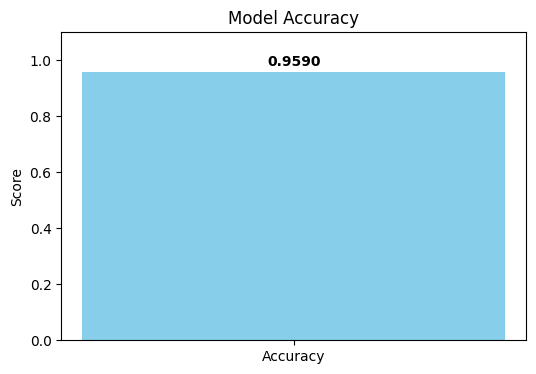

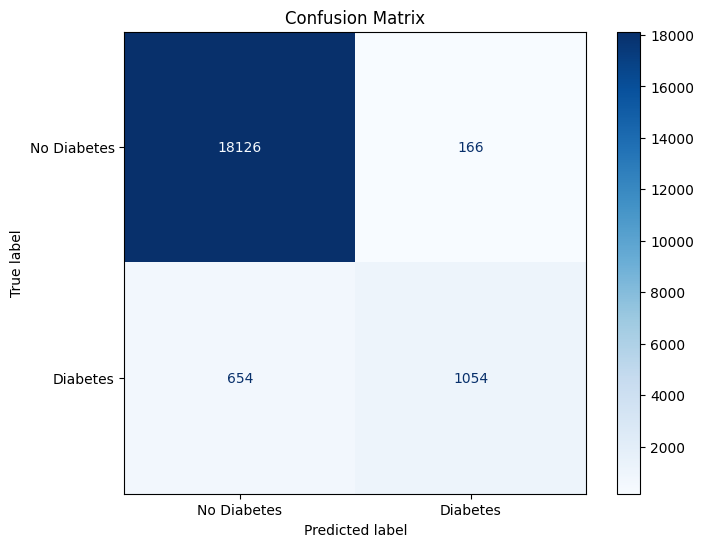

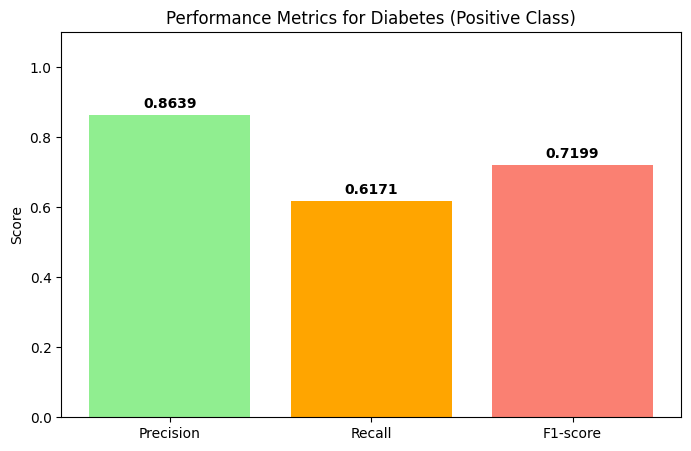

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

#Getting the predictions
y_pred = model.predict(X_test)

#Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

#Plotting Accuracy
plt.figure(figsize=(6, 4))
plt.bar(['Accuracy'], [accuracy], color='skyblue')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Model Accuracy')
plt.text(0, accuracy + 0.02, f"{accuracy:.4f}", ha='center', fontweight='bold')
plt.savefig('accuracy_plot.png')

#Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')

#Precision, Recall, and F1-Score (for the Diabetes class)
report = classification_report(y_test, y_pred, output_dict=True)
metrics_names = ['Precision', 'Recall', 'F1-score']
metrics_values = [report['1']['precision'], report['1']['recall'], report['1']['f1-score']]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_values, color=['lightgreen', 'orange', 'salmon'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Performance Metrics for Diabetes (Positive Class)')
for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.savefig('classification_metrics.png')

___________

**Exercise 5 :**

Visualizing the performance of our model
Visualize the decision boundary with accuracy information.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


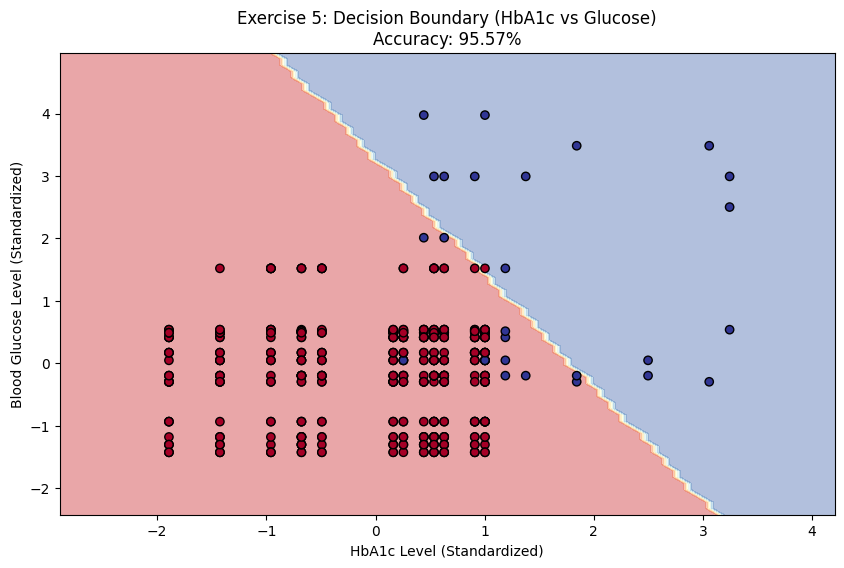

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

features_to_plot = ['HbA1c_level', 'blood_glucose_level']
X_plot = X_train[features_to_plot]
y_plot = y_train

model_2d = LogisticRegression()
model_2d.fit(X_plot, y_plot)

#Creating a grid of points across the graph
x_min, x_max = X_plot.iloc[:, 0].min() - 1, X_plot.iloc[:, 0].max() + 1
y_min, y_max = X_plot.iloc[:, 1].min() - 1, X_plot.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

#Predicting the outcome
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#Calculating accuracy
acc_2d = model_2d.score(X_plot, y_plot)

#Plot the results
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu') # The "Boundary" zones
plt.scatter(X_plot.iloc[:500, 0], X_plot.iloc[:500, 1], c=y_plot[:500],
            edgecolors='k', cmap='RdYlBu', label='Actual Data')
plt.title(f'Exercise 5: Decision Boundary (HbA1c vs Glucose)\nAccuracy: {acc_2d:.2%}')
plt.xlabel('HbA1c Level (Standardized)')
plt.ylabel('Blood Glucose Level (Standardized)')
plt.show()

____________

**Exercise 6 :**

ROC Curve
Plot the ROC Curve

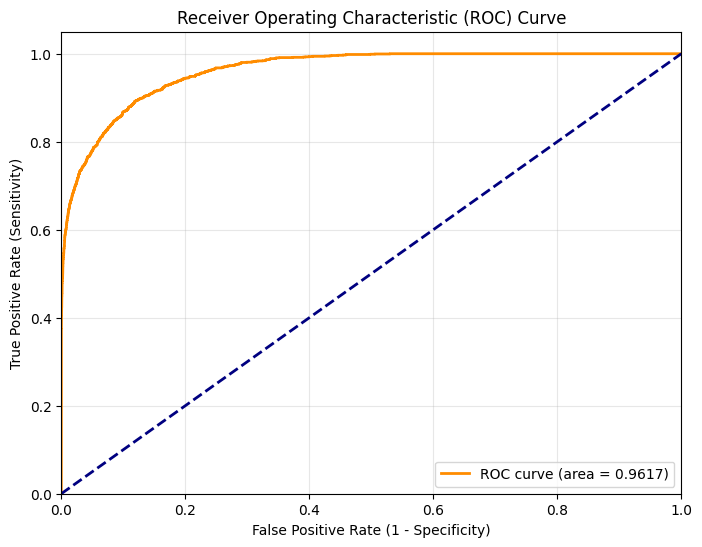

Final AUC Score: 0.9617


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

roc_auc = auc(fpr, tpr)

#Plot the ROC Curve:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final AUC Score: {roc_auc:.4f}")

This project successfully developed a machine learning pipeline to predict diabetes using a Logistic Regression model, achieving an outstanding AUC-ROC score of 0.96 and an overall accuracy of 95.9%. Through systematic data preprocessing, including One-Hot Encoding for categorical variables and StandardScaler for normalization, I ensured that every feature—from age to blood glucose levels—was mathematically optimized for the model. The primary achievement was transforming a raw dataset of 100,000 records into a functional predictive tool that demonstrates a high capability for distinguishing between healthy and diabetic individuals.

The most critical insight gained from this exercise is that high accuracy can be misleading in imbalanced datasets. While the accuracy was nearly 96%, the Recall of 61.7% revealed that the model initially missed a significant portion of diabetic cases. This highlights the importance of using a Confusion Matrix and F1-Score to evaluate medical models where a "False Negative" (missing a diagnosis) carries much higher risk than a "False Positive." By visualizing the Decision Boundary, I confirmed that HbA1c and glucose levels are the most influential predictors, providing a clear biological and mathematical justification for the model's classifications.